# Classifying Penguins with Keras Day 2

In [2]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

c:\Users\jfigg\.conda\envs\keras_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
# drop Nan rows
penguins.dropna(inplace=True)

In [5]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: str


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [6]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

### Defining the model

In [41]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [42]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [43]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=30, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step - accuracy: 0.4104 - loss: 1.0871 - val_accuracy: 0.4074 - val_loss: 1.0680
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4151 - loss: 1.0781 - val_accuracy: 0.4259 - val_loss: 1.0586
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4151 - loss: 1.0694 - val_accuracy: 0.4259 - val_loss: 1.0494
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4151 - loss: 1.0608 - val_accuracy: 0.4259 - val_loss: 1.0403
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4198 - loss: 1.0524 - val_accuracy: 0.4259 - val_loss: 1.0315
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4245 - loss: 1.0442 - val_accuracy: 0.4259 - val_loss: 1.0227
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4245 - loss: 1.0363 - val_accuracy: 0.4259 - val_loss: 1.0143
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4292 - loss: 1.0285 - val_accuracy: 0.4259 - val_loss: 

### Evaluating on the test data

In [44]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

 Test Set Evaluation:
Test Accuracy: 0.4179
Test Precision: 0.2932
Test Recall: 0.4179
Test F1 Score: 0.3218
Test ROC AUC Score: 0.7802


### Evaluating model training using loss and accuracy

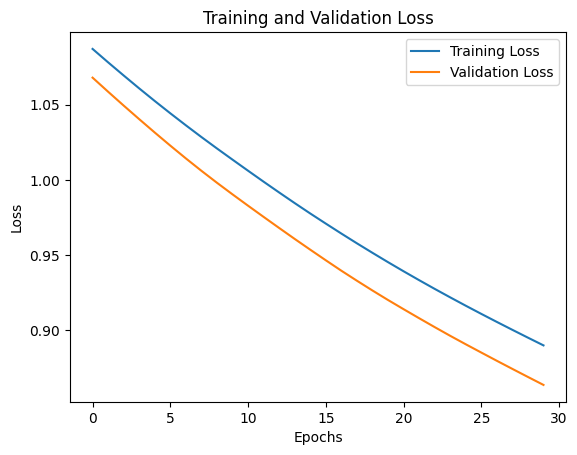

In [45]:
def plot_loss(history):
    # plot loss vs val_loss
    import matplotlib.pyplot as plt
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

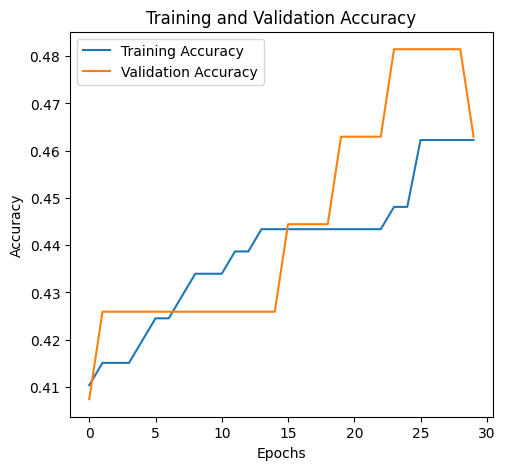

In [46]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

In [48]:
def plot_loss(history):
    # plot loss vs val_loss
    import matplotlib.pyplot as plt
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

def plot_accuracy(history):
    # plot the training and validation accuracy
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 5))     
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

def plot_loss_and_accuracy(history):
    return plot_loss(history), plot_accuracy(history)

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

I plotted the first 30 epochs so we can compare the "3" model runs.  While training and validation lost continuously fall, the training and validation accuracy is still settling.  Partly, it jumps around due to the small validation set (only 67 observations), meaning that small changes to the model can have outsized effects on predictions.  30 epochs is also not enough for the model to settle, so if we ran another 100 epochs, I would expect the model to reach its maximum fit, and training and validation accuracy should plateau, with validation accuracy residing just below training accuracy.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

In [49]:
keras.utils.set_random_seed(42)
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=30, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.5566 - loss: 1.0097 - val_accuracy: 0.5741 - val_loss: 0.9165
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5613 - loss: 0.9983 - val_accuracy: 0.5926 - val_loss: 0.9068
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5849 - loss: 0.9872 - val_accuracy: 0.6111 - val_loss: 0.8972
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5849 - loss: 0.9762 - val_accuracy: 0.6296 - val_loss: 0.8876
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6038 - loss: 0.9654 - val_accuracy: 0.6667 - val_loss: 0.8782
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6274 - loss: 0.9547 - val_accuracy: 0.7037 - val_loss: 0.8690
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6509 - loss: 0.9442 - val_accuracy: 0.7222 - val_loss: 0.8598
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6604 - loss: 0.9337 - val_accuracy: 0.7222 - val_loss: 

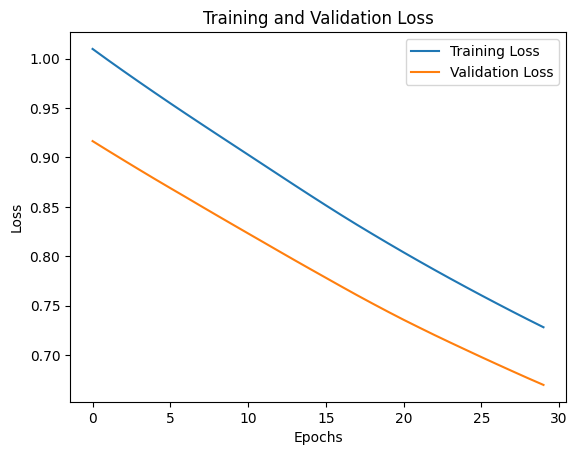

(None, None)

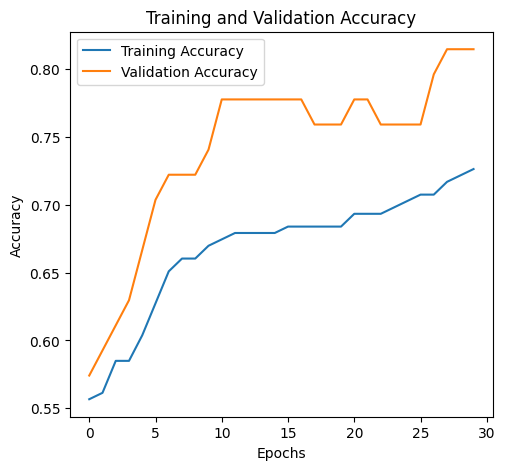

In [50]:
plot_loss_and_accuracy(history)

The random seed actually fixes the training and validation metrics, making the model repeatable (I'm running it on CPU, so it will be exact every time I reinitialize the model).  However, the random seed I chose led to terrible choices for initial weights, so the model after 30 epochs is barely better than guessing.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

I will set epochs=100 so that differences from the random weight initialization will have time to even out across the models.

#### Configuration 1
Adding a third hidden layer with 3 neurons

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7910 - loss: 0.6998 
Model Architecture:


Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359 (1.41 KB)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 240 (964.00 B)

None


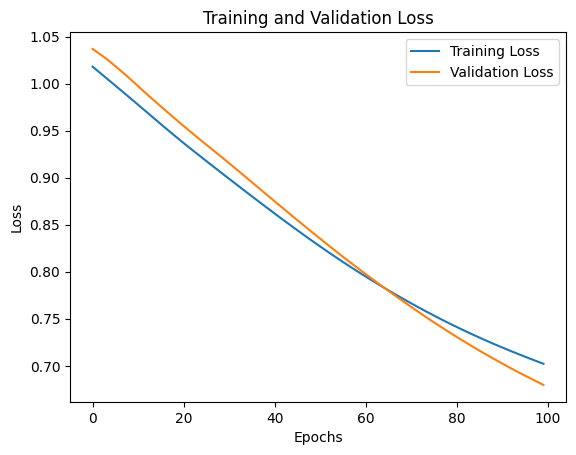

(None, None)

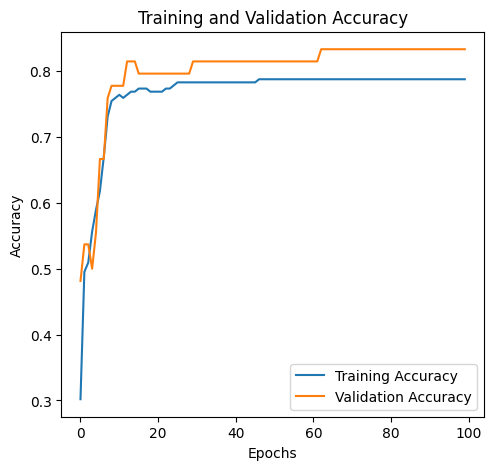

In [59]:
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
x = layers.Dense(3, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=100, 
                    validation_split=0.2, 
                    verbose=0)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

print("Model Architecture:")
print(model.summary())

plot_loss_and_accuracy(history)

#### Configuration 2:
Using a flat 5x5x5, 3-hidden layer NN

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7015 - loss: 0.8283 
Model Architecture:


Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341 (1.34 KB)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 228 (916.00 B)

None


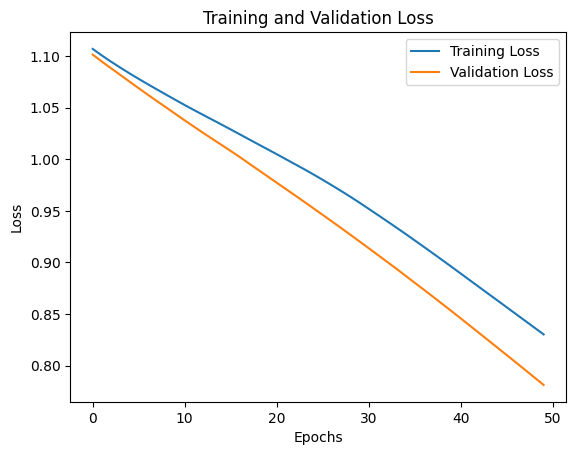

(None, None)

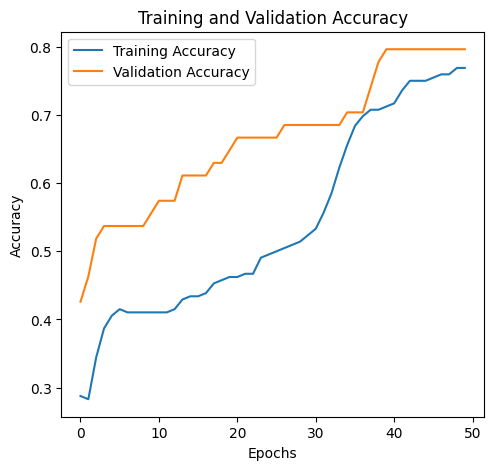

In [60]:
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(5, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
x = layers.Dense(5, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=50, 
                    validation_split=0.2, 
                    verbose=0)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

print("Model Architecture:")
print(model.summary())

plot_loss_and_accuracy(history)

#### Configuration 3
Monotonic, 3 hidden layer architecture (funnel then expand, like a U-NET model) (I hope this one does best)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7612 - loss: 0.7449 
Model Architecture:


Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 5)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332 (1.30 KB)

 Trainable params: 110 (440.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 222 (892.00 B)

None


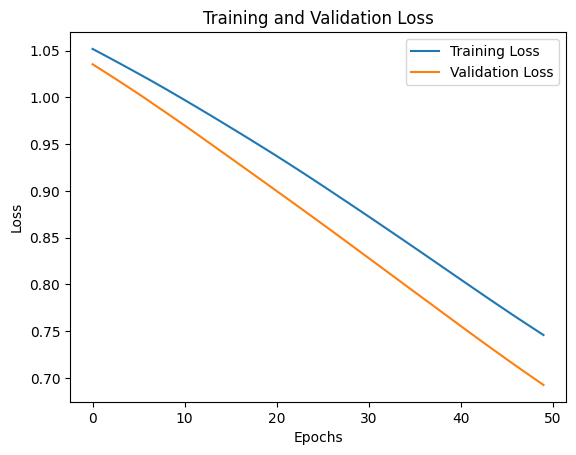

(None, None)

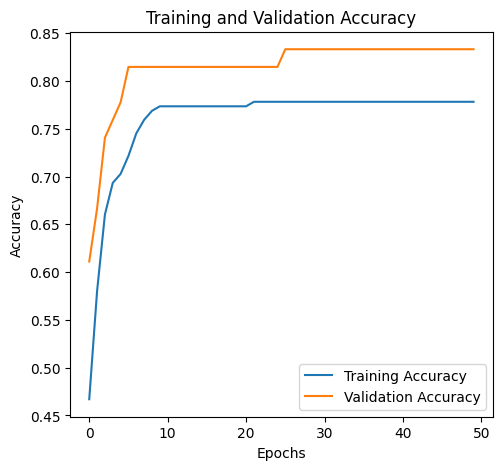

In [61]:
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(5, activation = 'relu')(inputs)
x = layers.Dense(4, activation = 'relu')(x)
x = layers.Dense(6, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=50, 
                    validation_split=0.2, 
                    verbose=0)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

print("Model Architecture:")
print(model.summary())

plot_loss_and_accuracy(history)

Keeping the same seed for all models and running for 100 epochs each, the funnel architecture did the best, with a validation accuracy of .79.  The monotonic structure was next, followed by the flat architecture model.

Strangely, the validation accuracy and loss are actually better than the train accuracy and loss.  I think this is because the train_test_split didn't actually stratify based on the output class that well, and because the model is probably worst with class 1, having fewer class 1 samples in the validation set artificially boosts the model's performance on the validation set.
| Data | class 0 | class 1 | class 2 |
| - | - | - | - |
| train data | 93 | 45 | 74 |
| validation data | 24 | 9 | 21 |

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

Since I use the same seed to retain comparability across models, I will just run a single model with 500 epocs, and look at the plots to see how the model performance changed.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0147 


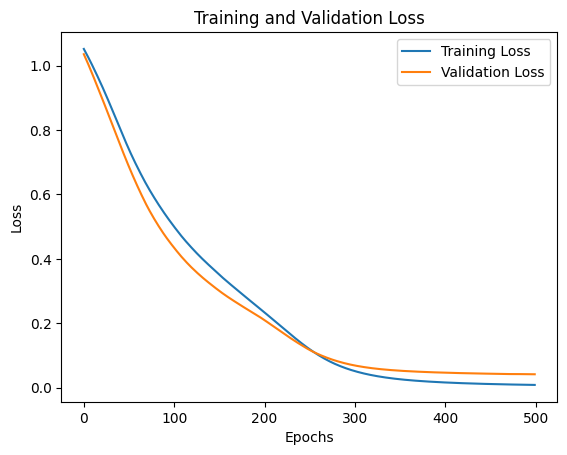

(None, None)

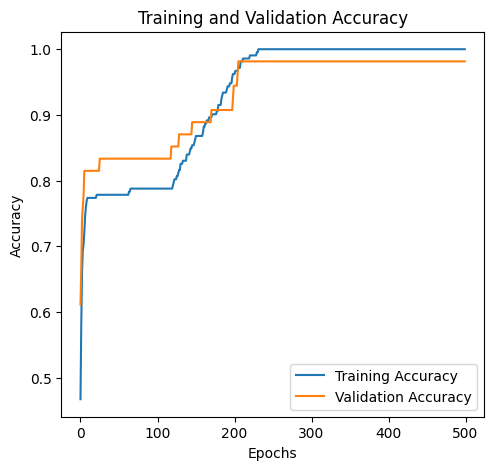

In [63]:
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(5, activation = 'relu')(inputs)
x = layers.Dense(4, activation = 'relu')(x)
x = layers.Dense(6, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=500, 
                    validation_split=0.2, 
                    verbose=0)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

plot_loss_and_accuracy(history)

While the train and validation loss both continued to decline all the way up to 500 epochs, if you look at train and validation accuracy, after around 225 epochs, validation accuracy failed to improve the rest of the way.  Due to the structure of the losses (exponential epoch increase for a linear loss decrease), you would probably need a lot more epochs (1000+) for validation accuracy to improve.  Let's test it:

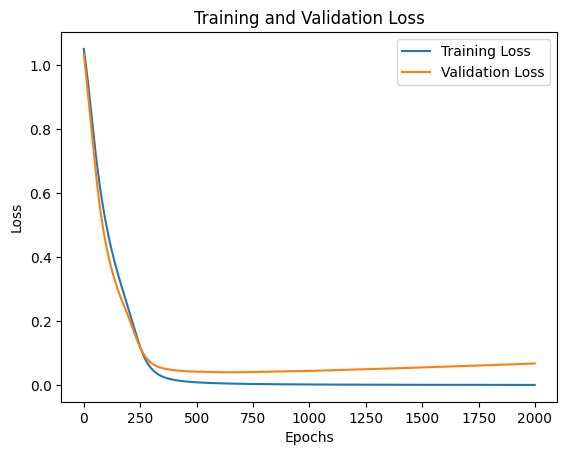

(None, None)

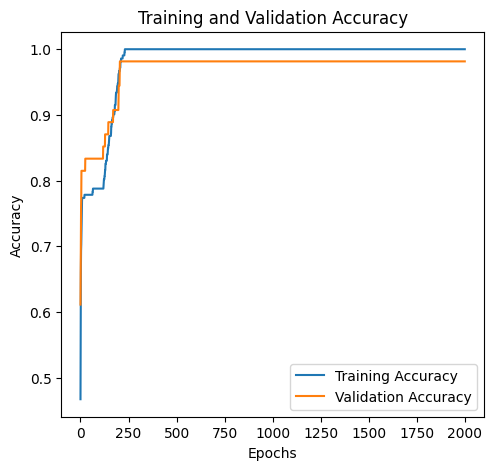

In [64]:
keras.utils.set_random_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(5, activation = 'relu')(inputs)
x = layers.Dense(4, activation = 'relu')(x)
x = layers.Dense(6, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=2000, 
                    validation_split=0.2, 
                    verbose=0)

plot_loss_and_accuracy(history)

Contrary to my beliefs, the validation accuracy failed to improve, and at some point around 500-750 epochs, the model began to really overfit, and validation loss began to deteriotate.

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [65]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.1,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3305 - loss: 1.2549 - val_accuracy: 0.1111 - val_loss: 1.2431
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3096 - loss: 1.2400 - val_accuracy: 0.5185 - val_loss: 1.2380
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3556 - loss: 1.2415 - val_accuracy: 0.5185 - val_loss: 1.2335
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4100 - loss: 1.2303 - val_accuracy: 0.5185 - val_loss: 1.2289
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4268 - loss: 1.2286 - val_accuracy: 0.5185 - val_loss: 1.2241
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4310 - loss: 1.2208 - val_accuracy: 0.5185 - val_loss: 1.2189
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4310 - loss: 1.2189 - val_accuracy: 0.5185 - val_loss: 1.2137
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4310 - loss: 1.2153 - val_accuracy: 0.5185 - val_loss:

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

While I like verbose=1 for model fitting, I don't want it for 20 optuna trials, so I will leave it.  I increase epochs to 100, and didn't touch validation size.  Another change I made is to make 4 hidden layers a possibility.

In [76]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 4)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    keras.backend.clear_session()
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=100,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=0,
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-14 19:03:56,351] A new study created in memory with name: no-name-fa560ea1-4c04-4582-bb97-83f8df51275c
[I 2026-05-14 19:04:02,974] Trial 0 finished with value: 0.03388252109289169 and parameters: {'num_layers': 3, 'learning_rate': 0.0014020885003608566, 'batch_size': 16, 'num_units_layer_1': 6, 'num_units_layer_2': 16, 'num_units_layer_3': 27}. Best is trial 0 with value: 0.03388252109289169.
[I 2026-05-14 19:04:09,640] Trial 1 finished with value: 0.036182910203933716 and parameters: {'num_layers': 4, 'learning_rate': 0.0005266264484283831, 'batch_size': 16, 'num_units_layer_1': 13, 'num_units_layer_2': 11, 'num_units_layer_3': 30, 'num_units_layer_4': 25}. Best is trial 0 with value: 0.03388252109289169.
[I 2026-05-14 19:04:17,756] Trial 2 finished with value: 0.026170050725340843 and parameters: {'num_layers': 3, 'learning_rate': 0.0018974263228807916, 'batch_size': 64, 'num_units_layer_1': 19, 'num_units_layer_2': 18, 'num_units_layer_3': 9}. Best is trial 2 with value: 

Best validation loss: 0.0044204480946063995
Best parameters: {'num_layers': 4, 'learning_rate': 0.007063599276384621, 'batch_size': 32, 'num_units_layer_1': 20, 'num_units_layer_2': 20, 'num_units_layer_3': 12, 'num_units_layer_4': 15}


In [77]:
# visualizing Optuna results
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                   14, 15, 16, 17, 18, 19],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [16, 16, 64, 64, 32, 16, 16, 64, 32, 64, 64, 16, 64, 16, 32,
                    32, 32, 32, 32, 64],
              'xaxis': 'x',
              'y': [0.03388252109289169, 0.036182910203933716,
                    0.026170050725340843, 1.0129714012145996, 0.3879578113555908,
                    0.037468813359737396, 0.07932771742343903, 0.0352051816880703,
                    0.053701773285865784, 0.6271719336509705, 0.047350361943244934,
                    0.04829845577478409, 0.0634232759475708, 0.04375012591481209,
                    0.032744381576776505, 0.043837953358888626,
                    0.027507996186614037, 0.04355902969837189,
                    0.0044204480946063995, 0.01807795837521553],
              'yaxis': 'y'},
             {'marker': {'color': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                   14, 15, 16, 17, 18, 19],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.0014020885003608566, 0.0005266264484283831,
                    0.0018974263228807916, 0.0001457595705408818,
                    0.0001298664839875829, 0.0022786554005993272,
                    0.0002137044476343747, 0.003634942279996125,
                    0.00028825480716040085, 0.00011138377185529097,
                    0.008246697072575604, 0.0011315144797547352,
                    0.0012847786492662938, 0.0027103476336652918,
                    0.0007683065773869799, 0.0006031126049597711,
                    0.0005639420742753952, 0.0004004319063459604,
                    0.007063599276384621, 0.009000659140905306],
              'xaxis': 'x2',
              'y': [0.03388252109289169, 0.036182910203933716,
                    0.026170050725340843, 1.0129714012145996, 0.3879578113555908,
                    0.037468813359737396, 0.07932771742343903, 0.0352051816880703,
                    0.053701773285865784, 0.6271719336509705, 0.047350361943244934,
                    0.04829845577478409, 0.0634232759475708, 0.04375012591481209,
                    0.032744381576776505, 0.0438

In [78]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3491 - loss: 1.0516 - val_accuracy: 0.6296 - val_loss: 0.8117
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7028 - loss: 0.7576 - val_accuracy: 0.8333 - val_loss: 0.5942
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8255 - loss: 0.5557 - val_accuracy: 0.8333 - val_loss: 0.3912
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8255 - loss: 0.3951 - val_accuracy: 0.9259 - val_loss: 0.2571
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9104 - loss: 0.2478 - val_accuracy: 0.9444 - val_loss: 0.1364
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9764 - loss: 0.0962 - val_accuracy: 0.9815 - val_loss: 0.0513
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9906 - loss: 0.0292 - val_accuracy: 0.9815 - val_loss: 0.0416
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 0.9815 - val_loss: 0.0274
Epoch 

My best model did end up having 4 hidden layers.  While many models performed well, the optuna training seemed like overkill for this data, since even weaker architectures I tried performed well after enough epochs.